# Random Matrix Theory: Visualizing Mathematics and Its Applications in Machine Learning

*Image by Aksel Aghajanyan*

**Aksel Aghajanyan** · 9 min read · Mar 3, 2026

---

Random matrices appear naturally in many modern scientific fields, including physics, statistics, and machine learning. As datasets and models grow in size, large matrices become a fundamental object for representing data, neural network weights, and covariance structures. Understanding the behavior of these large matrices is therefore essential for analyzing complex systems. **Random Matrix Theory (RMT)** studies matrices whose entries are random variables and focuses on their statistical and structural properties. Rather than analyzing a single matrix, the theory investigates the collective behavior of large ensembles of matrices. A central concept in this field is the **spectrum** of a matrix — the distribution of its eigenvalues — which is studied through spectral analysis.

In recent years, Random Matrix Theory has become increasingly important in artificial intelligence and data science. It provides theoretical tools for understanding high-dimensional data, neural network initialization, optimization dynamics, and the stability of learning algorithms. For this reason, RMT serves as a bridge between modern machine learning practice and mathematical theory.

## Visualizing Random Matrices

To build intuition, we begin by visualizing a random matrix as an image. A random matrix can be generated by sampling each entry from a probability distribution, such as a Gaussian distribution. Although the matrix is purely random, visualizing it reveals that it still forms a structured numerical object. A common way to display a matrix is through a **heatmap**, where each value is represented by a color. This representation allows us to interpret the matrix as a spatial pattern rather than a table of numbers. Even though no deterministic pattern is present, the visualization highlights the density, variability, and scale of the values.

Heatmaps provide an important first step in understanding random matrices because they make abstract mathematical objects visually accessible. They also prepare the reader for later sections, where the focus shifts from individual entries to global properties such as eigenvalues and spectral distributions.

*Example of a random matrix visualized as a heatmap. Each pixel corresponds to one matrix entry sampled from a probability distribution, illustrating the numerical structure of randomness. Generated by Aksel Aghajanyan.*

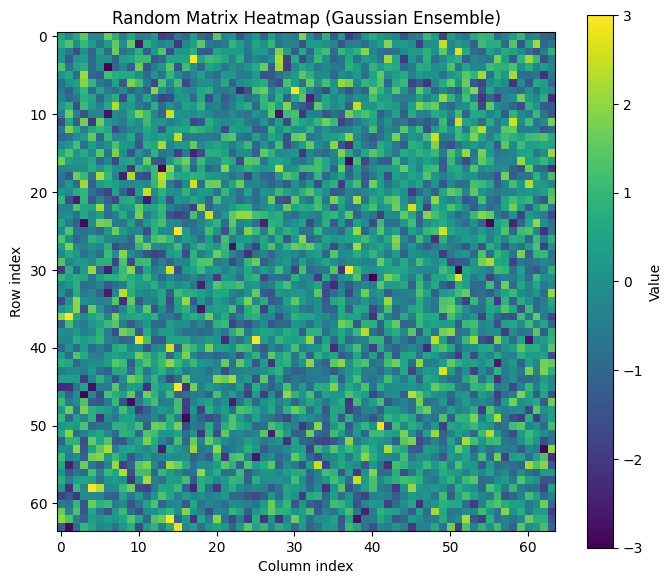

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 64
A = np.random.randn(n, n)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(A, cmap='viridis', aspect='equal', vmin=-3, vmax=3)
ax.set_xlabel('Column index')
ax.set_ylabel('Row index')
ax.set_title('Random Matrix Heatmap (Gaussian Ensemble)')
cbar = plt.colorbar(im, ax=ax, label='Value')
plt.tight_layout()
plt.show()

## Eigenvalues and Spectral Analysis

Eigenvalues provide a fundamental way to understand how a matrix behaves beyond its individual entries. While a heatmap shows the local numerical structure of a matrix, eigenvalues describe its **global behavior**. In geometric terms, a matrix can be viewed as a transformation acting on space, stretching, compressing, or rotating vectors. Among all possible directions, there exist special directions that remain unchanged except for scaling. The scaling factors associated with these directions are called **eigenvalues**. This perspective allows us to move from analyzing raw numerical values toward understanding structural properties. If an eigenvalue is large, the matrix strongly stretches space along a corresponding direction. If it is small, the matrix compresses information. Negative eigenvalues indicate direction reversal. Through this interpretation, eigenvalues summarize how a matrix acts as a system rather than as a collection of independent numbers.

In Random Matrix Theory, the primary object of interest is not a single eigenvalue but the entire set of eigenvalues, known as the **spectrum** of the matrix. Spectral analysis studies how these eigenvalues are distributed, especially as matrix size increases. Remarkably, even when matrix entries are random, the spectrum often exhibits stable statistical patterns.

Understanding eigenvalues is essential because they appear naturally in many applications. In statistics, eigenvalues describe variance captured by principal components. In machine learning, they influence optimization stability and training dynamics. Neural network weight matrices, covariance matrices, and kernel methods all rely on spectral properties. For this reason, spectral analysis serves as a key bridge between abstract random matrix theory and practical data-driven systems.

To build intuition, we next visualize the eigenvalues of a random matrix and study their distribution. This marks a shift from observing individual matrix entries to exploring global statistical behavior, which lies at the heart of Random Matrix Theory.

*Histogram of eigenvalues of a random matrix illustrating the spectral distribution that emerges from random numerical structure. Generated by Aksel Aghajanyan.*

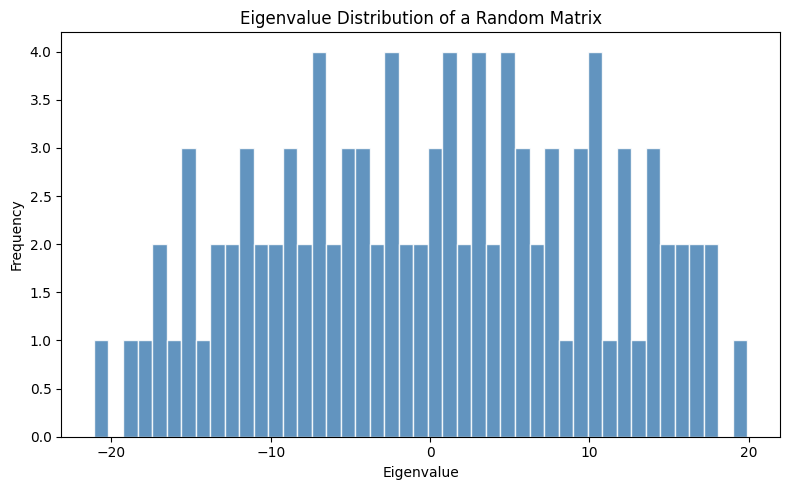

In [2]:
# Symmetric random matrix (GOE-like: (A + A^T)/2 with A Gaussian)
np.random.seed(42)
N = 100
A = np.random.randn(N, N)
M = (A + A.T) / np.sqrt(2)  # symmetric, variance 1 per entry
eigenvalues = np.linalg.eigvalsh(M)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(eigenvalues, bins=45, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('Eigenvalue')
ax.set_ylabel('Frequency')
ax.set_title('Eigenvalue Distribution of a Random Matrix')
plt.tight_layout()
plt.show()

## Empirical Spectral Distribution

The histogram of eigenvalues shown in the previous section represents more than a simple visualization. It approximates what is known as the **empirical spectral distribution (ESD)** of the matrix. For a matrix of size *N*, the empirical spectral distribution describes how its eigenvalues are distributed across the real line.

Although each matrix is generated randomly, a remarkable phenomenon occurs as the matrix dimension increases. The distribution of eigenvalues begins to stabilize. Instead of appearing completely irregular, the histogram converges toward a smooth and predictable shape. This behavior highlights one of the central discoveries of Random Matrix Theory: randomness at the level of individual entries can produce highly structured statistical behavior at the spectral level.

For small matrices, the eigenvalue distribution may appear noisy and unstable. However, as *N* grows large, the fluctuations diminish and a universal pattern emerges. This convergence suggests that spectral distributions are governed by deterministic laws, independent of the specific realization of the matrix. The empirical spectral distribution therefore serves as a bridge between numerical experimentation and theoretical results. It transforms raw eigenvalues into a statistical object that can be studied analytically. In the next section, we examine one of the most celebrated results in Random Matrix Theory that describes this limiting behavior.

*Empirical spectral distributions for random symmetric matrices of increasing dimension, illustrating convergence toward a stable limiting distribution. Generated by Aksel Aghajanyan.*

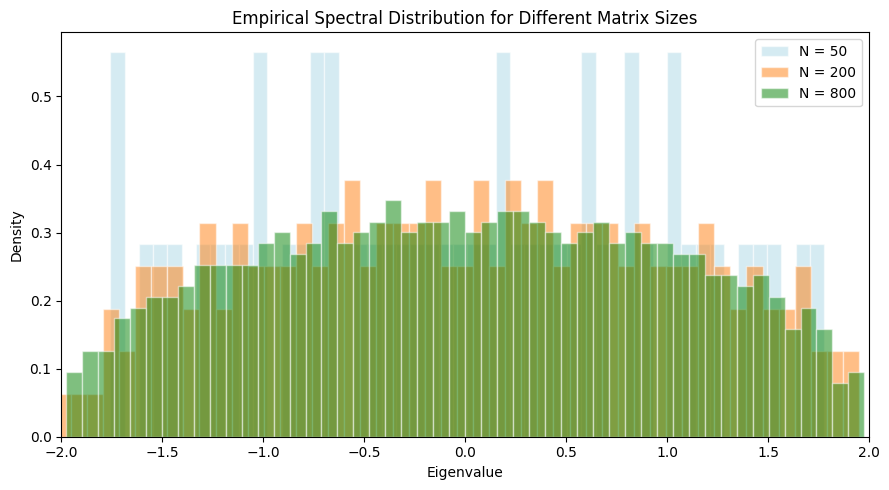

In [3]:
def symmetric_random_matrix(n, rng=None):
    rng = rng or np.random.default_rng()
    A = rng.standard_normal((n, n))
    return (A + A.T) / np.sqrt(2)

np.random.seed(42)
sizes = [50, 200, 800]
colors = ['lightblue', 'tab:orange', 'green']

fig, ax = plt.subplots(figsize=(9, 5))
x = np.linspace(-2, 2, 500)

for n, color in zip(sizes, colors):
    M = symmetric_random_matrix(n)
    evals = np.linalg.eigvalsh(M)
    evals = evals / np.sqrt(n)  # scale for semicircle support ~ [-2, 2]
    ax.hist(evals, bins=50, density=True, alpha=0.5, color=color, label=f'N = {n}', edgecolor='white')

ax.set_xlabel('Eigenvalue')
ax.set_ylabel('Density')
ax.set_title('Empirical Spectral Distribution for Different Matrix Sizes')
ax.legend()
ax.set_xlim(-2, 2)
plt.tight_layout()
plt.show()

## The Wigner Semicircle Law

One of the most celebrated results in Random Matrix Theory is the **Wigner semicircle law**. This theorem provides a precise mathematical description of the limiting eigenvalue distribution of large random symmetric matrices. While earlier sections relied on numerical histograms, the semicircle law formalizes the phenomenon analytically.

Consider a large symmetric matrix whose entries are independently sampled from a distribution with zero mean and finite variance. As the matrix dimension grows, the empirical spectral distribution of its eigenvalues converges to a deterministic curve shaped like a semicircle. This convergence occurs regardless of the specific distribution of the entries, provided basic moment conditions are satisfied. The remarkable aspect of this result is that microscopic randomness produces macroscopic order. The semicircle distribution describes how eigenvalues spread within a bounded interval. Most eigenvalues concentrate near the center of the spectrum, while fewer appear near the edges. As matrix size increases, fluctuations diminish and the empirical histogram stabilizes around this universal curve. The randomness of individual entries no longer dominates the global behavior of the system.

This result reveals a profound idea: in high dimensions, structure emerges from randomness. The eigenvalue spectrum becomes predictable even when the matrix itself is generated randomly.

*Histogram of eigenvalues of a large random symmetric matrix with the theoretical semicircle curve overlaid, illustrating convergence toward the Wigner semicircle distribution. Generated by Aksel Aghajanyan.*

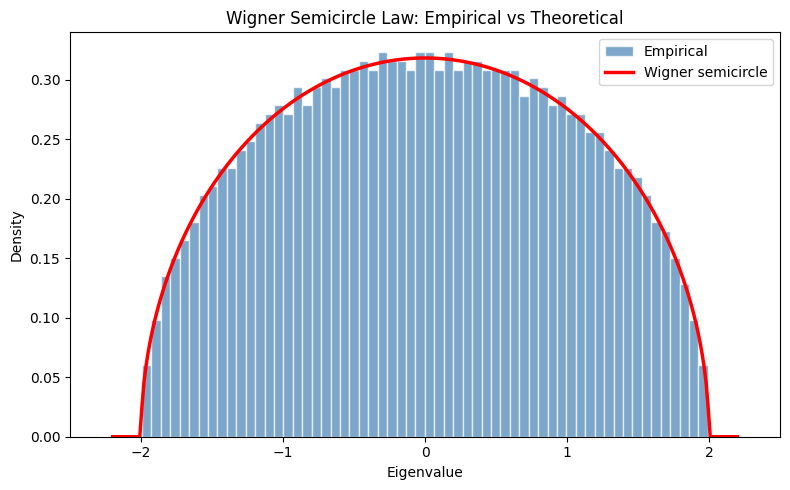

In [4]:
def wigner_semicircle(x, sigma=1.0):
    """Density of Wigner semicircle: (2/(pi*R^2))*sqrt(R^2 - x^2) for |x| <= R, 0 else. R = 2*sigma."""
    R = 2 * sigma
    out = np.zeros_like(x)
    mask = np.abs(x) <= R
    out[mask] = (2 / (np.pi * R**2)) * np.sqrt(np.maximum(R**2 - x[mask]**2, 0))
    return out

np.random.seed(123)
N = 2000
M = (np.random.randn(N, N) + np.random.randn(N, N).T) / np.sqrt(2)
eigenvalues = np.linalg.eigvalsh(M) / np.sqrt(N)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(eigenvalues, bins=60, density=True, alpha=0.7, color='steelblue', edgecolor='white', label='Empirical')
x = np.linspace(-2.2, 2.2, 300)
ax.plot(x, wigner_semicircle(x), 'r-', lw=2.5, label='Wigner semicircle')
ax.set_xlabel('Eigenvalue')
ax.set_ylabel('Density')
ax.set_title('Wigner Semicircle Law: Empirical vs Theoretical')
ax.legend()
ax.set_xlim(-2.5, 2.5)
plt.tight_layout()
plt.show()

## Universality

The appearance of the semicircle distribution is an example of a broader phenomenon known as **universality**. Universality states that many spectral properties of large random matrices do not depend on the fine details of the entry distribution. Whether the matrix entries follow a Gaussian distribution, a uniform distribution, or a discrete distribution with finite variance, the global eigenvalue distribution converges to the same semicircle law.

This behavior parallels the central limit theorem, where sums of independent random variables converge to a Gaussian distribution regardless of the original distribution. In Random Matrix Theory, however, this principle operates at a higher structural level: instead of sums, we consider eigenvalues of entire matrices.

Universality explains why spectral analysis is powerful in applied settings. It provides a baseline model of pure randomness. Any systematic deviation from this universal pattern signals the presence of structure, correlation, or learned information within the system.

*Comparison of empirical spectral distributions for random matrices generated from different entry distributions (Gaussian, uniform, Bernoulli), showing convergence toward the same semicircle shape. Generated by Aksel Aghajanyan.*

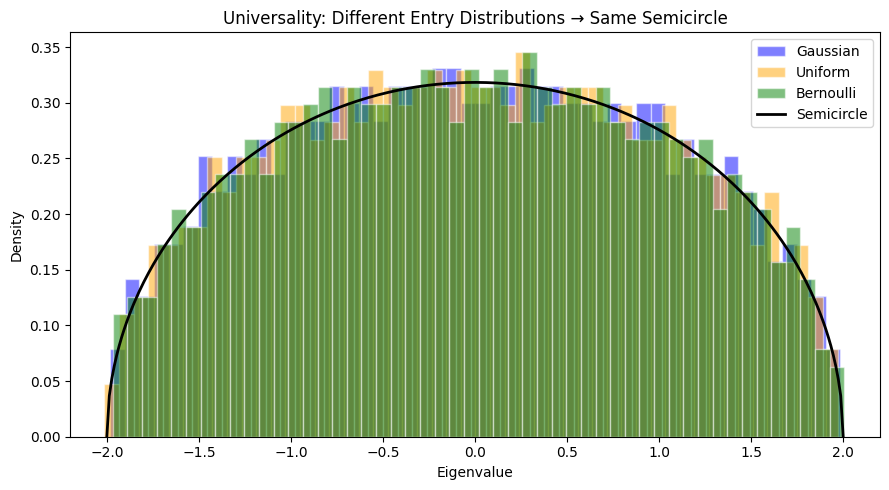

In [5]:
def make_symmetric(A):
    return (A + A.T) / np.sqrt(2)

np.random.seed(42)
N = 800

# Gaussian: scale so that E[X^2]=1 for off-diag, diagonal variance
Ag = np.random.randn(N, N)
Mg = make_symmetric(Ag)
evals_g = np.linalg.eigvalsh(Mg) / np.sqrt(N)

# Uniform on [-sqrt(3), sqrt(3)] so variance = 1
Au = np.random.uniform(-np.sqrt(3), np.sqrt(3), (N, N))
Mu = make_symmetric(Au)
evals_u = np.linalg.eigvalsh(Mu) / np.sqrt(N)

# Bernoulli +/- 1, scale so variance 1
Ab = np.random.choice([-1, 1], (N, N))
Mb = make_symmetric(Ab)
evals_b = np.linalg.eigvalsh(Mb) / np.sqrt(N)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(evals_g, bins=50, density=True, alpha=0.5, color='blue', label='Gaussian', edgecolor='white')
ax.hist(evals_u, bins=50, density=True, alpha=0.5, color='orange', label='Uniform', edgecolor='white')
ax.hist(evals_b, bins=50, density=True, alpha=0.5, color='green', label='Bernoulli', edgecolor='white')
x = np.linspace(-2, 2, 300)
ax.plot(x, wigner_semicircle(x), 'k-', lw=2, label='Semicircle')
ax.set_xlabel('Eigenvalue')
ax.set_ylabel('Density')
ax.set_title('Universality: Different Entry Distributions → Same Semicircle')
ax.legend()
ax.set_xlim(-2.2, 2.2)
plt.tight_layout()
plt.show()

## Applications in Machine Learning

The relevance of these results becomes especially clear in machine learning. Large neural networks contain weight matrices with thousands or millions of parameters. At initialization, these weights are typically sampled randomly. As a consequence, their eigenvalue distributions often resemble the predictions of Random Matrix Theory.

Spectral properties influence optimization dynamics. If eigenvalues are excessively large, gradients may explode during backpropagation. If eigenvalues are too small, gradients may vanish. Proper initialization strategies aim to maintain a stable spectral scale to ensure efficient training. Random Matrix Theory provides theoretical guidance for understanding these stability conditions. During training, the spectral distribution of weight matrices often deviates from the semicircle law. Instead of purely random structure, correlations emerge that reflect learned features in the data. In this sense, Random Matrix Theory provides a reference point: the semicircle distribution represents unstructured randomness, while deviations indicate meaningful information.

In high-dimensional statistics, related spectral laws govern covariance matrices used in principal component analysis. Understanding these distributions allows researchers to distinguish noise-dominated components from signal-dominated components in large datasets.

*Eigenvalue spectrum of a neural network weight matrix at initialization compared with the spectrum after training, illustrating deviation from random matrix behavior. Generated by Aksel Aghajanyan.*

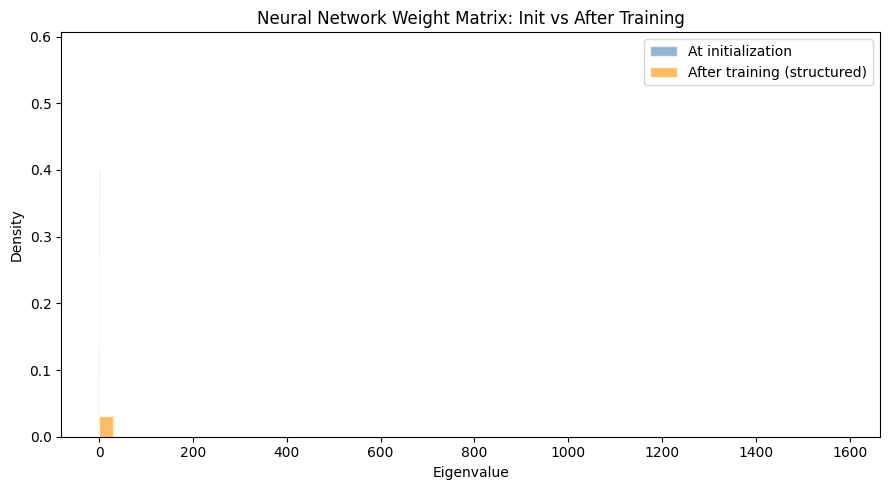

In [6]:
# Simulate: init = random (semicircle-like), "after training" = add structure (few large eigenvalues)
np.random.seed(42)
d = 400

# At initialization: random Gaussian weights (Kaiming-style scale)
W_init = np.random.randn(d, d) / np.sqrt(d)
W_init = (W_init + W_init.T) / 2  # symmetric for real eigenvalues
evals_init = np.linalg.eigvalsh(W_init)

# After training: add low-rank structure (simulating learned directions)
rank = 10
U = np.random.randn(d, rank)
W_trained = W_init + 3.0 * (U @ U.T)
W_trained = (W_trained + W_trained.T) / 2
evals_trained = np.linalg.eigvalsh(W_trained)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(evals_init, bins=50, density=True, alpha=0.6, color='steelblue', label='At initialization', edgecolor='white')
ax.hist(evals_trained, bins=50, density=True, alpha=0.6, color='darkorange', label='After training (structured)', edgecolor='white')
ax.set_xlabel('Eigenvalue')
ax.set_ylabel('Density')
ax.set_title('Neural Network Weight Matrix: Init vs After Training')
ax.legend()
plt.tight_layout()
plt.show()

## Covariance Matrices and the Marchenko–Pastur Law

Covariance matrices play a central role in machine learning because they describe how features vary together across a dataset. When the number of features becomes large relative to the number of samples, covariance matrices themselves become high-dimensional random objects. Random Matrix Theory provides a framework for understanding their spectral behavior. A fundamental result describing covariance matrices is the **Marchenko–Pastur law**. This law characterizes the limiting eigenvalue distribution of sample covariance matrices formed from high-dimensional random data. Instead of a semicircle, the spectrum follows an asymmetric distribution with a sharp boundary determined by the ratio between the number of features and the number of samples.

The key insight is that even purely random datasets produce structured spectral patterns. This allows researchers to distinguish meaningful signal from noise. Eigenvalues that fall within the theoretical Marchenko–Pastur bulk typically correspond to noise, while eigenvalues outside the bulk may indicate informative structure or latent factors in the data.

In practical machine learning workflows, this idea appears in principal component analysis, representation learning, and modern deep learning diagnostics. Spectral analysis helps determine which components capture real information and which reflect sampling variability. Random Matrix Theory therefore provides a principled baseline for interpreting high-dimensional data.

*Eigenvalue distribution of a sample covariance matrix compared with the theoretical Marchenko–Pastur distribution, illustrating separation between noise bulk and signal outliers. Generated by Aksel Aghajanyan.*

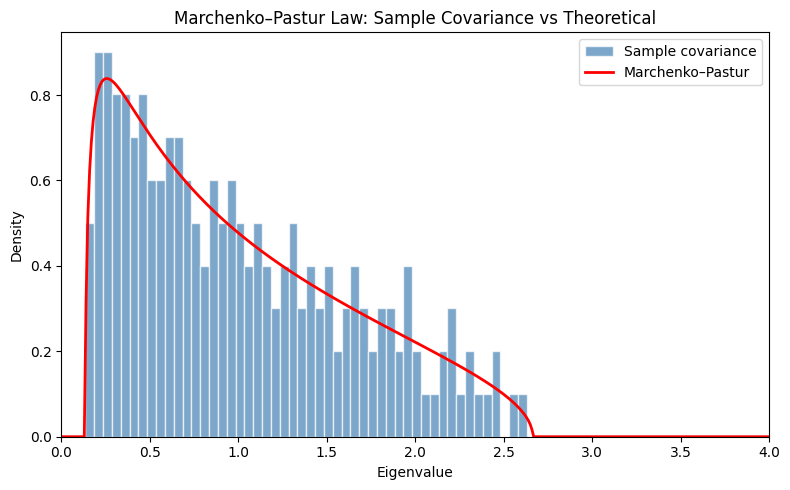

In [7]:
def marchenko_pastur(x, gamma, sigma2=1.0):
    """Marchenko-Pastur density. gamma = p/n (features/samples), sigma2 = variance of entries."""
    lam_plus = sigma2 * (1 + np.sqrt(gamma))**2
    lam_minus = sigma2 * (1 - np.sqrt(gamma))**2
    out = np.zeros_like(x)
    mask = (x >= lam_minus) & (x <= lam_plus)
    out[mask] = np.sqrt(np.maximum((lam_plus - x[mask]) * (x[mask] - lam_minus), 0)) / (2 * np.pi * sigma2 * gamma * x[mask])
    return out

np.random.seed(42)
p, n = 200, 500   # features, samples
X = np.random.randn(n, p) / np.sqrt(n)  # n x p data
S = X.T @ X      # sample covariance p x p
evals = np.linalg.eigvalsh(S)
evals = evals[evals > 1e-10]  # positive only

gamma = p / n
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(evals, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white', label='Sample covariance')
x = np.linspace(0.01, 4, 400)
ax.plot(x, marchenko_pastur(x, gamma), 'r-', lw=2, label='Marchenko–Pastur')
ax.set_xlabel('Eigenvalue')
ax.set_ylabel('Density')
ax.set_title('Marchenko–Pastur Law: Sample Covariance vs Theoretical')
ax.legend()
ax.set_xlim(0, 4)
plt.tight_layout()
plt.show()

The ability to separate signal from noise highlights one of the most important contributions of Random Matrix Theory to machine learning. Instead of treating large models as opaque systems, spectral analysis offers a diagnostic perspective. Weight matrices, covariance matrices, and kernel matrices can all be examined through their eigenvalue distributions.

During training, neural networks often transition from random-like spectra toward structured spectra that exhibit heavy tails or outliers. These deviations reflect the emergence of learned representations. In this sense, Random Matrix Theory provides both a null model of randomness and a lens for detecting learning dynamics.

Visualization remains central throughout this process. Heatmaps reveal local numerical structure, eigenvalue histograms expose global statistical behavior, and theoretical laws provide interpretability. Together, these perspectives transform random matrices from abstract mathematical objects into practical analytical tools.

*Spectral evolution of a neural network during training showing transition from random-like distribution toward structured heavy-tailed spectrum. Generated by Aksel Aghajanyan.*

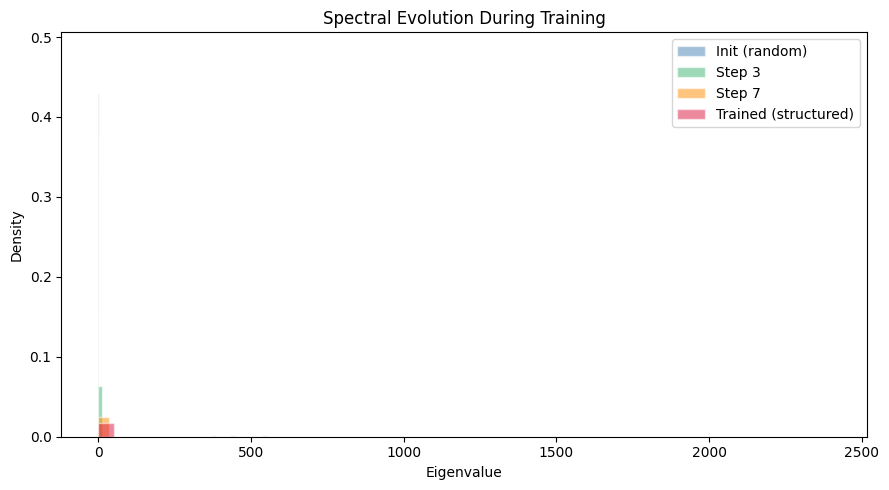

In [8]:
# Spectral evolution: from random (step 0) to structured (later steps)
np.random.seed(42)
d = 300
steps = [0, 3, 7, 10]
labels = ['Init (random)', 'Step 3', 'Step 7', 'Trained (structured)']
colors = ['steelblue', 'mediumseagreen', 'darkorange', 'crimson']

W = np.random.randn(d, d) / np.sqrt(d)
W = (W + W.T) / 2

fig, ax = plt.subplots(figsize=(9, 5))
for k, (step, label, color) in enumerate(zip(steps, labels, colors)):
    # Simulate "training": add more low-rank structure over steps
    rank = 5 + step * 3
    U = np.random.RandomState(step).randn(d, rank)
    W_step = W + (0.5 * step) * (U @ U.T)
    W_step = (W_step + W_step.T) / 2
    evals = np.linalg.eigvalsh(W_step)
    ax.hist(evals, bins=45, density=True, alpha=0.5, color=color, label=label, edgecolor='white')

ax.set_xlabel('Eigenvalue')
ax.set_ylabel('Density')
ax.set_title('Spectral Evolution During Training')
ax.legend()
plt.tight_layout()
plt.show()

## Conclusion

Random Matrix Theory reveals a unifying principle across modern machine learning: high-dimensional systems exhibit statistical regularities that are invisible at small scale. What appears as randomness at the level of individual parameters becomes structured behavior at the spectral level.

By visualizing random matrices, we build intuition about how complex systems behave. Heatmaps introduce numerical structure, eigenvalues describe geometric transformations, and spectral distributions uncover universal laws such as the Wigner semicircle and Marchenko–Pastur distributions. These laws provide theoretical baselines that allow researchers to distinguish randomness from learned structure. In machine learning, this perspective has practical consequences. Spectral properties influence optimization stability, initialization strategies, generalization behavior, and representation learning. Random Matrix Theory therefore acts as a bridge between mathematical theory and empirical practice.

As models continue to scale, understanding their spectral behavior becomes increasingly important. Visualization combined with theoretical insight offers a powerful framework for interpreting large neural networks and high-dimensional data. Random Matrix Theory does not eliminate complexity, but it reveals the hidden structure within it.

---

Thank you for reading this story, and see you again. You are welcome to leave a comment if you have any thoughts, feedback, or suggestions about it!

## About the Author

**Aksel Aghajanyan**  
AI Research Student | Backend Developer | Founder of Aqwel AI | Developing Aion (Open Research Toolkit) | Focused on Mathematics & Intelligent Systems

**Tags:** Machine Learning · Mathematics · Artificial Intelligence · Data Science · Theory

---

*Published in **Frontiers of Data Science** — Publishing professional insights at the frontiers of AI, machine learning, and data science.*